In [19]:
# Load libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from sklearn.metrics import confusion_matrix, classification_report

In [20]:
#load dataset
df = pd.read_csv('butterflies and moths.csv')

In [21]:
#preview dataset
print('Columns:', df.columns.tolist())
print(df['data set'].value_counts())
df.head()

Columns: ['class id', 'filepaths', 'labels', 'data set']
data set
train    12594
test       500
valid      500
Name: count, dtype: int64


,class id,filepaths,labels,data set
0,0,train/ADONIS/001.jpg,ADONIS,train
1,0,train/ADONIS/002.jpg,ADONIS,train
2,0,train/ADONIS/003.jpg,ADONIS,train
3,0,train/ADONIS/004.jpg,ADONIS,train
4,0,train/ADONIS/005.jpg,ADONIS,train


In [22]:
#Data Preprocessing
#Showing Pixel Value Range (Before Normalization)
sample_path = df[df['data set'] == 'train']['filepaths'].iloc[0]

img = load_img(sample_path)          # Load original 
img_array = img_to_array(img)        # Convert to NumPy array

print('Before Normalization:')
print(f'  Min pixel value: {np.min(img_array):.0f}')   
print(f'  Max pixel value: {np.max(img_array):.0f}')   

# Normalize to [0, 1]
normalized_img = img_array / 255

print('\nAfter Normalization:')
print(f'  Min pixel value: {np.min(normalized_img):.4f}')  
print(f'  Max pixel value: {np.max(normalized_img):.4f}')  


Before Normalization:
  Min pixel value: 0
  Max pixel value: 255

After Normalization:
  Min pixel value: 0.0000
  Max pixel value: 1.0000


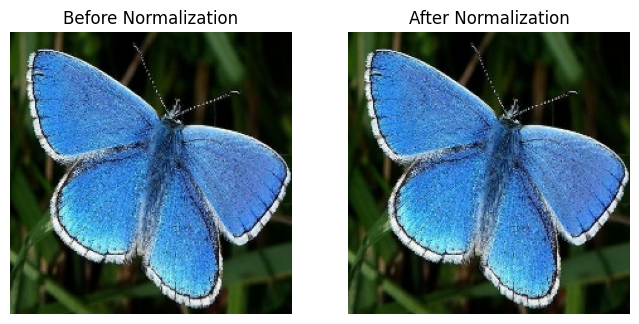

In [23]:
#Comparing Before vs After Normalization
plt.figure(figsize=(8, 4))

# Before normalization
plt.subplot(1, 2, 1)
plt.imshow(img_array.astype('uint8'))
plt.title('Before Normalization')
plt.axis('off')

# After normalization
plt.subplot(1, 2, 2)
plt.imshow(normalized_img)
plt.title('After Normalization')
plt.axis('off')

plt.show()

In [24]:
#Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,        # Randomly rotate images up to 20 degrees
    width_shift_range=0.1,    # Horizontal shift
    height_shift_range=0.1,   # Vertical shift
    horizontal_flip=True,     # Randomly flip images left/right
    zoom_range=0.1            # Randomly zoom-in
)

#Test generator
test_datagen = ImageDataGenerator(rescale=1./255)

df_train = df[df['data set'] == 'train']
df_test  = df[df['data set'] == 'test']

print(f'Training samples : {len(df_train)}')
print(f'Test samples     : {len(df_test)}')

Training samples : 12594
Test samples     : 500


In [25]:
#Training Images
train = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col='filepaths',
    y_col='labels',
    target_size=(64, 64), #Resizes images to 64 x 64 pixels
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

Found 12594 validated image filenames belonging to 100 classes.


In [26]:
#Testing Images
test = test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col='filepaths',
    y_col='labels',
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 500 validated image filenames belonging to 100 classes.


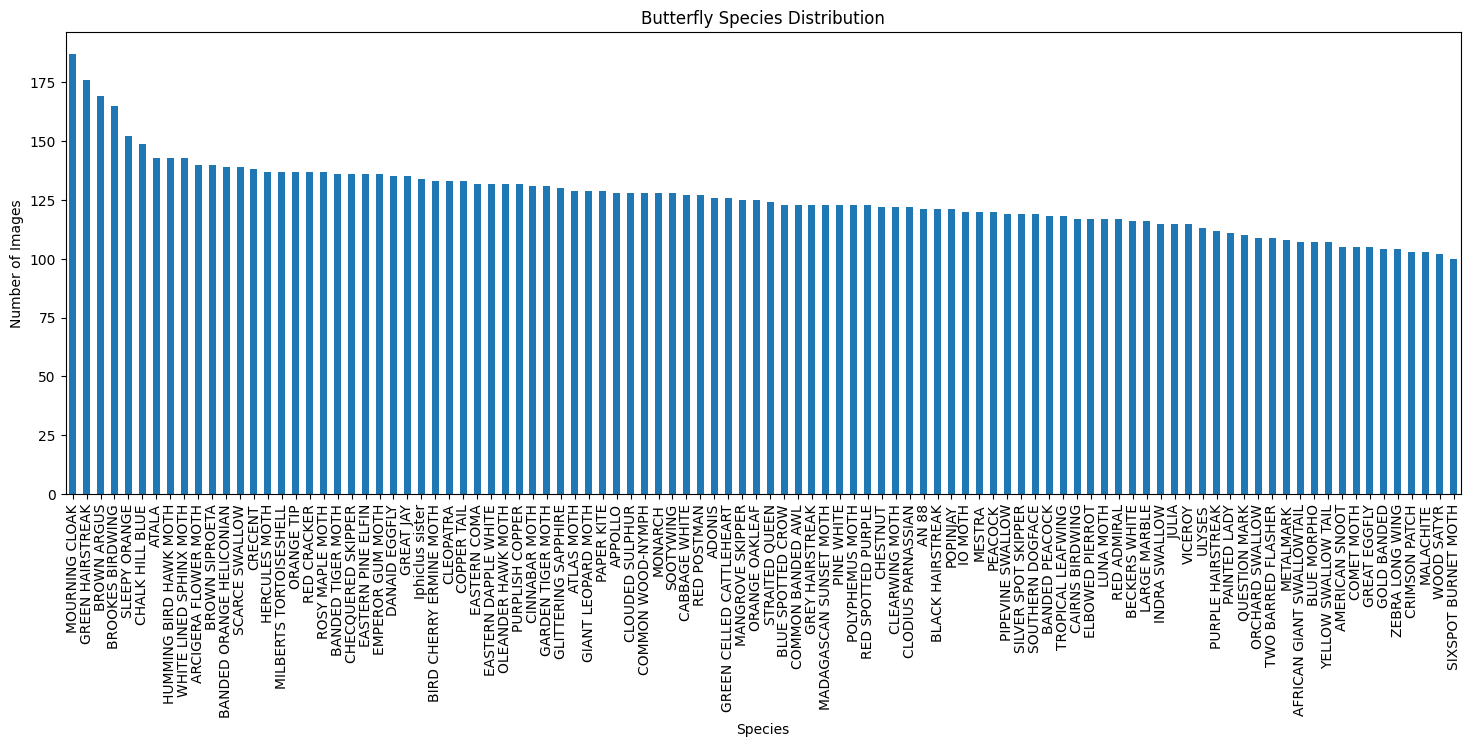

Total training images : 12594
Most common class     : MOURNING CLOAK (187 images)
Least common class    : SIXSPOT BURNET MOTH (100 images)


In [27]:
#Data Visualization
plt.figure(figsize=(18,6))
label_counts = df[df['data set'] == 'train']['labels'].value_counts()
label_counts.plot(kind='bar')
plt.title("Butterfly Species Distribution")
plt.xlabel('Species')
plt.ylabel("Number of Images")
plt.show()

print(f'Total training images : {len(df_train)}')
print(f'Most common class     : {label_counts.idxmax()} ({label_counts.max()} images)')
print(f'Least common class    : {label_counts.idxmin()} ({label_counts.min()} images)')

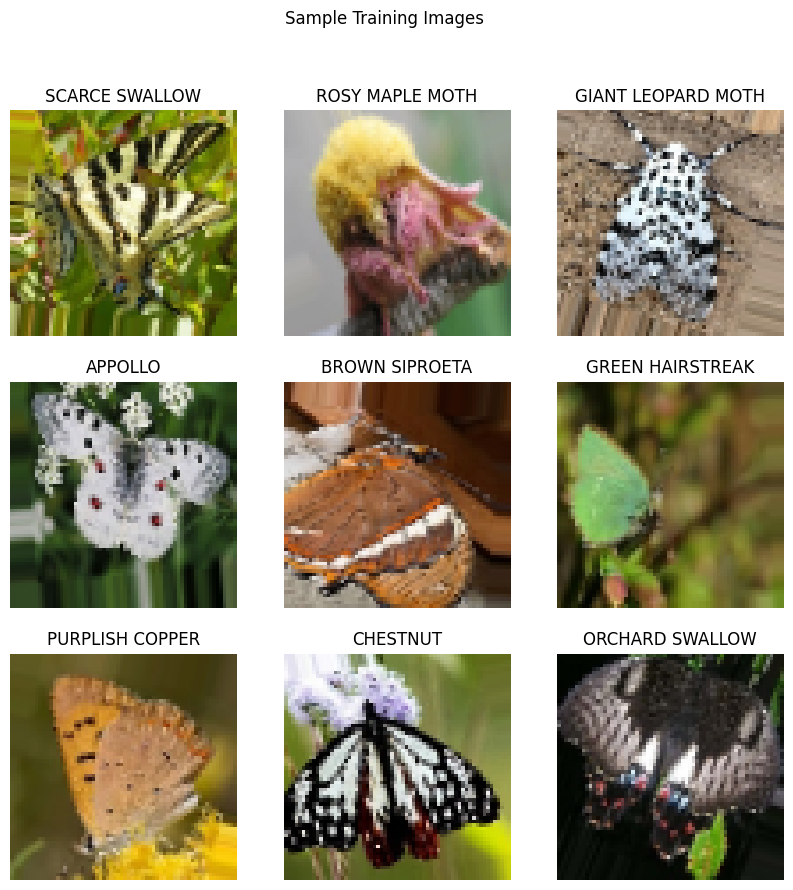

In [28]:
#Display sample images
x, y = next(train)

idx= {v: k for k, v in train.class_indices.items()}

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x[i])
    label_name = idx[np.argmax(y[i])]
    plt.title(label_name)
    plt.axis('off')
    plt.suptitle('Sample Training Images')
plt.show() 

In [29]:
#Build CNN model 
model = Sequential([
    #detect low-level features
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2,2),

    #detect mid-level features
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    #detect higher-level features
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    #Flatten 3D features to a 1D vector
    Flatten(), 

    #Fully connected layer
    Dense(256, activation='relu'), 

    #Dropout
    Dropout(0.4),

    #Output layer
    Dense(len(train.class_indices), activation='softmax') 
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,298,852 (4.95 MB)

 Trainable params: 1,298,852 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
#Model Training
history = model.fit(
    train, 
    validation_data=test, 
    epochs=10
)

Epoch 1/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.0940 - loss: 3.8842 - val_accuracy: 0.2900 - val_loss: 2.8644
Epoch 2/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.2779 - loss: 2.8140 - val_accuracy: 0.3680 - val_loss: 2.4819
Epoch 3/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.3985 - loss: 2.2719 - val_accuracy: 0.4240 - val_loss: 2.4962
Epoch 4/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.4653 - loss: 1.9691 - val_accuracy: 0.6060 - val_loss: 1.4620
Epoch 5/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.5259 - loss: 1.7478 - val_accuracy: 0.6640 - val_loss: 1.2690
Epoch 6/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.5600 - loss: 1.5929 - val_accuracy: 0.6700 - val_loss: 1.1291
Epoch 7/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.5907 - loss: 1.4567 - val_accuracy: 0.6820 - val_loss: 1.2053
Epoch 8/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.6172 - loss: 1.3614 - 

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7460 - loss: 0.8731
Final Test Loss: 0.8731
Final Test Accuracy: 74.60%


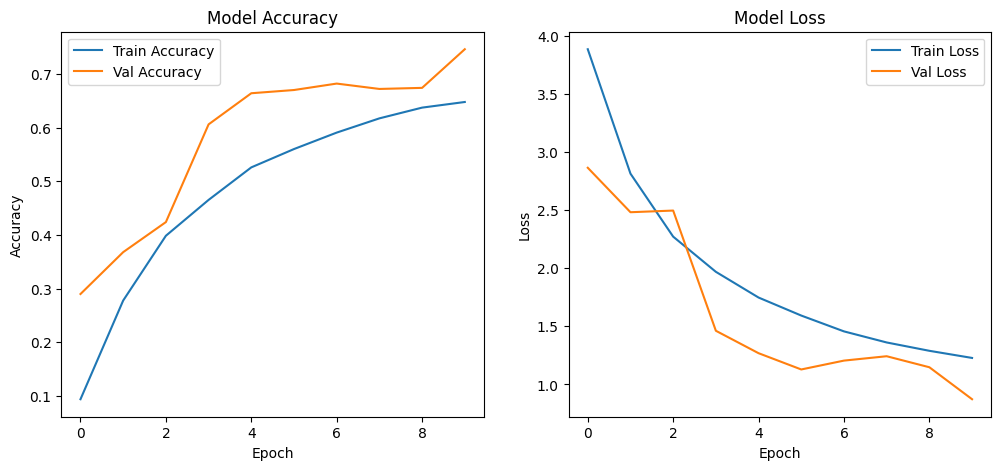

In [31]:
#Evaluation
#Loss and Accuracy
loss, acc = model.evaluate(test)
print(f"Final Test Loss: {loss:.4f}")
print(f"Final Test Accuracy: {acc*100:.2f}%")

# Plots 
plt.figure(figsize=(12, 5))

# Accuracy curves
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

#Loss curves
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


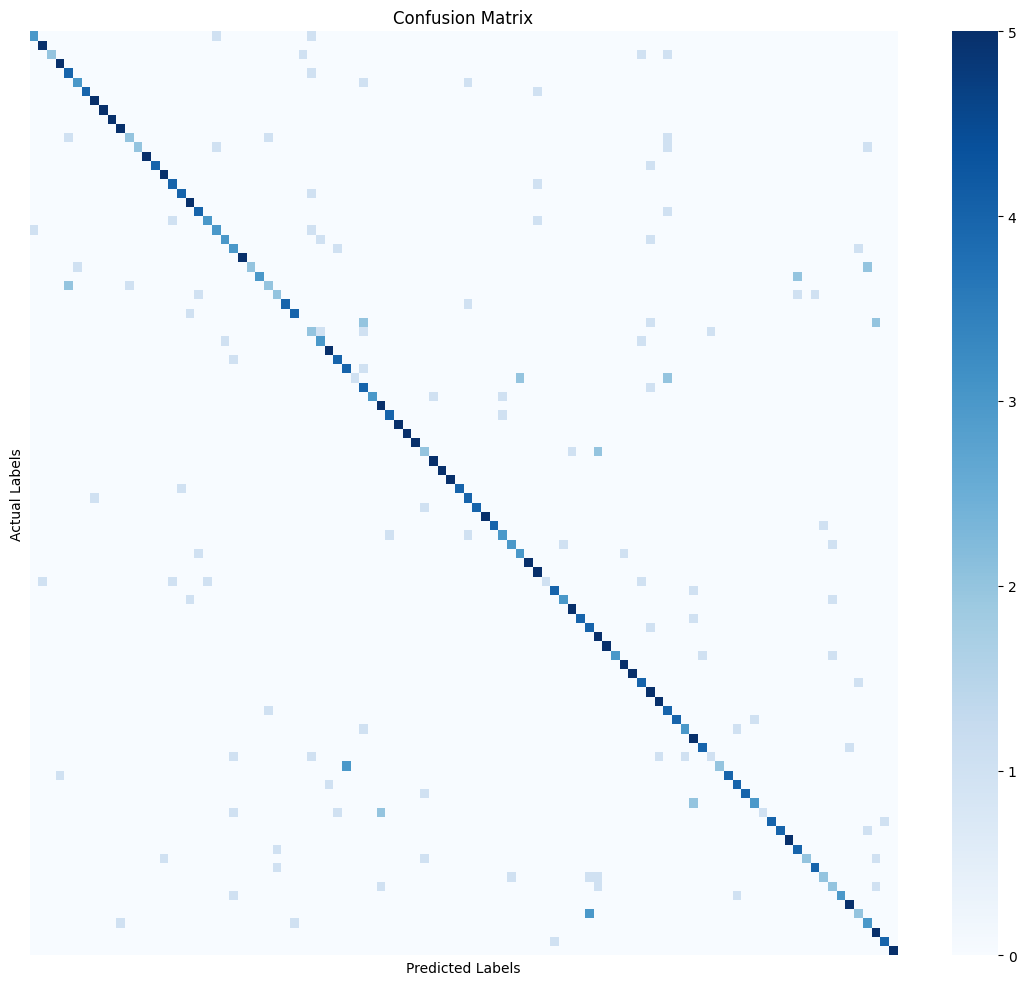

Correctly classified : 373 / 500 (74.60%)


In [32]:
#Confusion Matrix
test.reset() 

# Generate class predictions
Y_pred = model.predict(test)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test.classes

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the Confusion Matrix 
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=False, yticklabels=False) 
plt.title('Confusion Matrix')
plt.ylabel('Actual Labels')
plt.xlabel('Predicted Labels')

plt.show()

#correct predictions
correct = np.trace(cm)
total   = np.sum(cm)
print(f'Correctly classified : {correct} / {total} ({100 * correct / total:.2f}%)')


In [33]:
#Classification Report
class_names = list(train.class_indices.keys())

print('Classification Report')
print('=' * 60)
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report
                           precision    recall  f1-score   support

                   ADONIS       0.75      0.60      0.67         5
AFRICAN GIANT SWALLOWTAIL       0.83      1.00      0.91         5
           AMERICAN SNOOT       1.00      0.40      0.57         5
                    AN 88       0.83      1.00      0.91         5
                  APPOLLO       0.57      0.80      0.67         5
     ARCIGERA FLOWER MOTH       0.75      0.60      0.67         5
                    ATALA       1.00      0.80      0.89         5
               ATLAS MOTH       0.83      1.00      0.91         5
 BANDED ORANGE HELICONIAN       1.00      1.00      1.00         5
           BANDED PEACOCK       1.00      1.00      1.00         5
        BANDED TIGER MOTH       0.83      1.00      0.91         5
            BECKERS WHITE       0.67      0.40      0.50         5
  BIRD CHERRY ERMINE MOTH       1.00      0.40      0.57         5
         BLACK HAIRSTREAK       1.00   